#Batsman

In [1]:
%pip install langgraph

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [9]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb: float
    boudary_percentage: float
    summary: str

In [17]:
def calculate_sr(state: BatsmanState):
    sr = (state['runs']/state['balls'])/100
    
    return {'sr':sr}

In [18]:
def calculate_bpb(state: BatsmanState):
    bpb = state['balls']/(state['fours']+state['sixes'])
    
    return {'bpb':bpb}

In [19]:
def calculate_boudary_percentage(state: BatsmanState):
    boundary_percentage = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100
    return {'boudary_percentage' : boundary_percentage}

In [22]:
def summary(state: BatsmanState):
    summary = f"""
{state['sr']}\n
{state['boudary_percentage']}\n
{state['bpb']}\n
"""
    return {'summary' : summary}

In [23]:
graph = StateGraph(BatsmanState)
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boudary_percentage',calculate_boudary_percentage)
graph.add_node('summary',summary)


graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boudary_percentage')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boudary_percentage', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

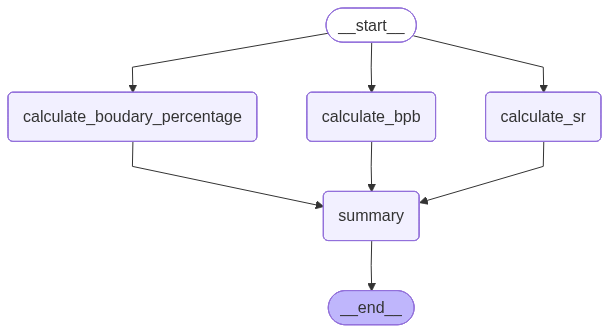

In [24]:
workflow

In [25]:
intial_state = {
    'runs' : 100,
    'balls' : 50,
    'fours' : 6,
    'sixes' : 4
}

workflow.invoke(intial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 0.02,
 'bpb': 5.0,
 'boudary_percentage': 48.0,
 'summary': '\n0.02\n\n48.0\n\n5.0\n\n'}